In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from data_loader import load_train_data
from preprocessing import compute_rul
from feature_engineering import build_baseline_features, fit_regime_clusters, assign_regimes, select_informative_sensors
from sklearn.model_selection import train_test_split

train_df = load_train_data("FD001")
train_df = compute_rul(train_df)

(20631, 26)


Text(0.5, 1.0, 'Engine lifespan distribution (FD001)')

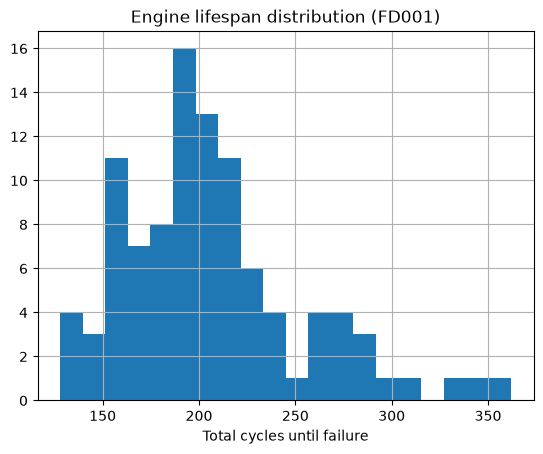

In [2]:
max_rul_per_engine = train_df.groupby("unit_number")["time_cycles"].max()
max_rul_per_engine.hist(bins=20)
plt.xlabel("Total cycles until failure")
plt.title("Engine lifespan distribution (FD001)")

Unit 1 sensor_3 range: 1577.6 to 1605.44
Unit 2 sensor_3 range: 1575.38 to 1610.1
Unit 3 sensor_3 range: 1577.22 to 1606.5
Unit 4 sensor_3 range: 1576.64 to 1612.11
Unit 5 sensor_3 range: 1574.8 to 1609.41


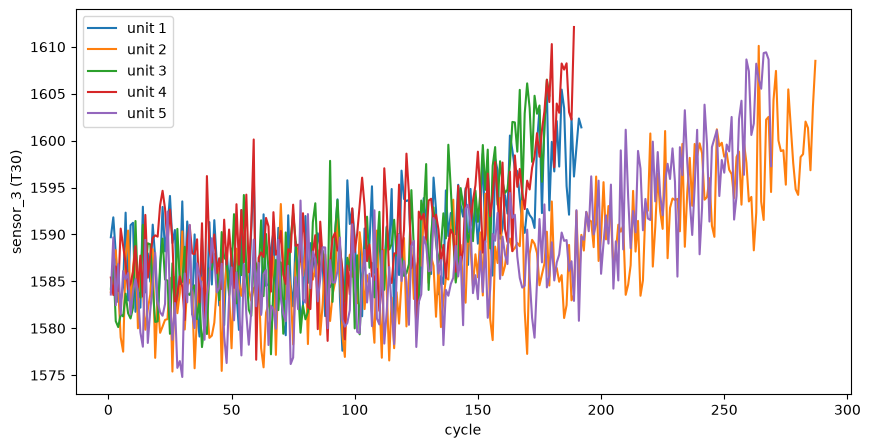

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_3"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_3 range: {unit_data['sensor_3'].min()} to {unit_data['sensor_3'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_3 (T30)")
ax.legend()

Unit 1 sensor_9 range: 9033.22 to 9061.21
Unit 2 sensor_9 range: 9044.62 to 9109.36
Unit 3 sensor_9 range: 9047.08 to 9197.52
Unit 4 sensor_9 range: 9045.33 to 9203.22
Unit 5 sensor_9 range: 9056.42 to 9157.05


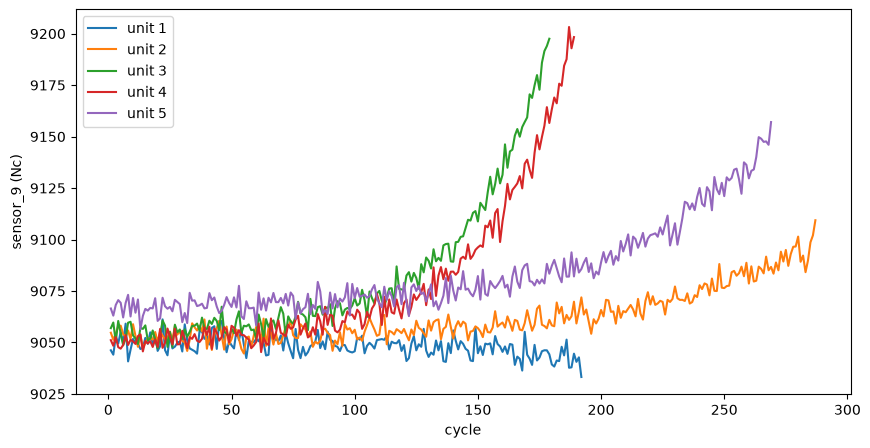

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_9"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_9 range: {unit_data['sensor_9'].min()} to {unit_data['sensor_9'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_9 (Nc)")
ax.legend()

Unit 1 sensor_1 range: 518.67 to 518.67
Unit 2 sensor_1 range: 518.67 to 518.67
Unit 3 sensor_1 range: 518.67 to 518.67
Unit 4 sensor_1 range: 518.67 to 518.67
Unit 5 sensor_1 range: 518.67 to 518.67


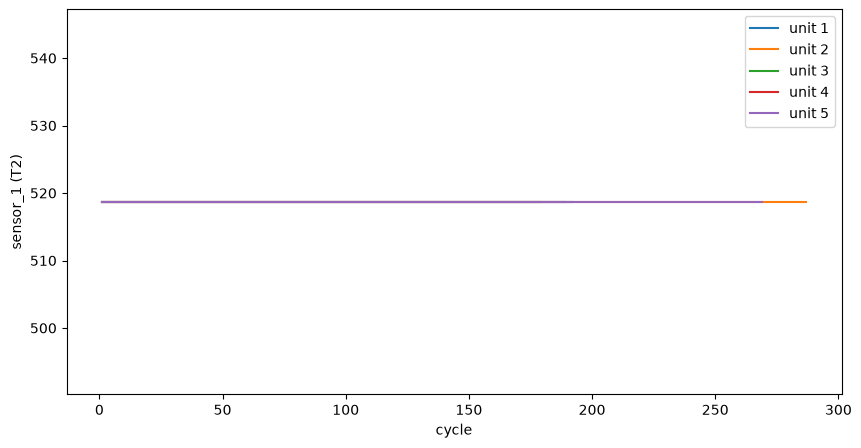

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_1"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_1 range: {unit_data['sensor_1'].min()} to {unit_data['sensor_1'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_1 (T2)")
ax.legend()

Unit 1 sensor_14 range: 8110.93 to 8140.58
Unit 2 sensor_14 range: 8129.68 to 8175.57
Unit 3 sensor_14 range: 8130.42 to 8255.34
Unit 4 sensor_14 range: 8125.32 to 8259.42
Unit 5 sensor_14 range: 8140.95 to 8215.19


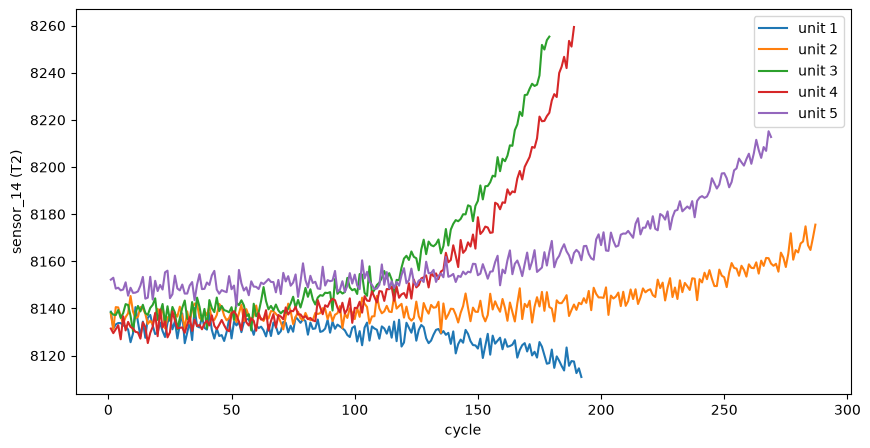

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_14"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_14 range: {unit_data['sensor_14'].min()} to {unit_data['sensor_14'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_14 (T2)")
ax.legend()

In [7]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]
variances = train_df[sensor_columns].var().sort_values()
print(variances)

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


Unit 1 sensor_15 range: 8.3682 to 8.5227
Unit 2 sensor_15 range: 8.3428 to 8.5377
Unit 3 sensor_15 range: 8.3682 to 8.5363
Unit 4 sensor_15 range: 8.3683 to 8.5462
Unit 5 sensor_15 range: 8.3536 to 8.541


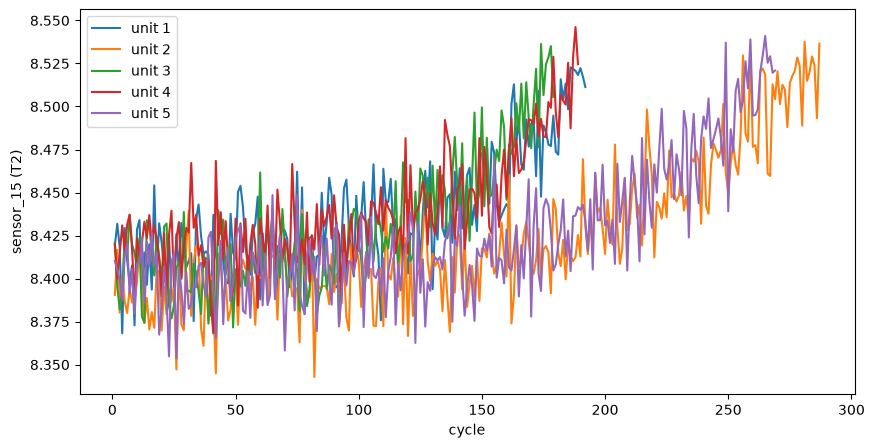

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_15"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_15 range: {unit_data['sensor_15'].min()} to {unit_data['sensor_15'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_15 (T2)")
ax.legend()

Unit 1 sensor_21 range: 22.9588 to 23.4999
Unit 2 sensor_21 range: 22.9721 to 23.6005
Unit 3 sensor_21 range: 22.9562 to 23.5181
Unit 4 sensor_21 range: 23.0135 to 23.5074
Unit 5 sensor_21 range: 23.0195 to 23.5503


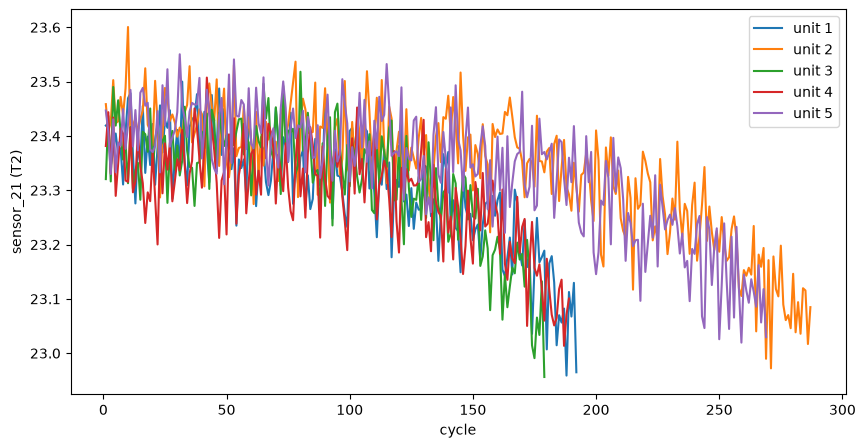

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["sensor_21"], label=f"unit {unit}")
    print(f"Unit {unit} sensor_21 range: {unit_data['sensor_21'].min()} to {unit_data['sensor_21'].max()}")
ax.set_xlabel("cycle")
ax.set_ylabel("sensor_21 (T2)")
ax.legend()

(20631, 26)


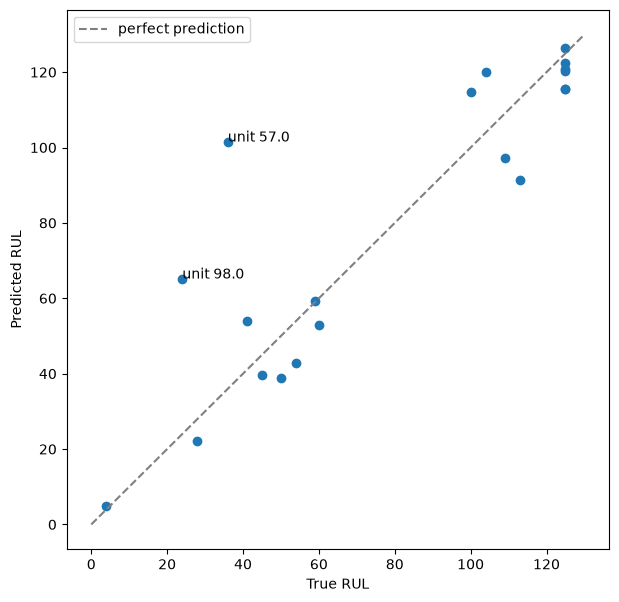

In [13]:
import matplotlib.pyplot as plt
from train_baseline import run_baseline_training
from scoring import evaluate, phm08_per_engine

model, per_engine_df, metrics = run_baseline_training()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(per_engine_df["true_RUL"], per_engine_df["predicted_RUL"])

# perfect-prediction reference line
lims = [0, 130]
ax.plot(lims, lims, linestyle="--", color="gray", label="perfect prediction")

# TODO: annotate the two outlier points (unit 57, unit 98) with their unit_id
# so you can visually identify them directly on the plot, not just from the table
# hint: ax.annotate(text, (x, y)) for each row where phm08_contribution is large
for _, row in per_engine_df.iterrows():
    if row["phm08_contribution"] > 50:
        ax.annotate(f"unit {row['unit_id']}", (row["true_RUL"], row["predicted_RUL"]))

ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.legend()
plt.show()